In [18]:
# ============================================================================
# Stage 1 MLP Baseline for Encrypted Traffic Classification
# 目标: 仅使用流级别统计特征 (s_i) 训练一个 MLP 分类器
# 用途: 作为后续 Time-aware Transformer 的性能下界 (Lower Bound)
# 对应 Proposal Section 5.3.1
# ============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ============================================================================
# 0. 全局配置与可复现性
# ============================================================================
def set_seed(seed=42):
    """固定随机种子，确保实验可复现"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] 使用设备: {device}")

# 实验配置（方便后续超参数调优）
CONFIG = {
    'data_path': '../dataset/ar002_et12_20260511_002-stage1_flows.csv',     # CSV 文件路径
    'label_col': 'label',                 # 标签列名
    'test_size': 0.2,                     # 测试集比例
    'val_size': 0.1,                      # 验证集比例（从训练集中划分）
    'batch_size': 256,                    # 批次大小
    'learning_rate': 1e-3,               # 学习率
    'weight_decay': 1e-5,                # L2 正则化系数
    'num_epochs': 500,                    # 最大训练轮数
    'early_stop_patience': 15,            # 早停耐心值
    'hidden_dims': [512, 256, 128, 64],       # MLP 隐藏层维度
    'dropout': 0.25,                       # Dropout 比率
    'use_class_weights': True,            # 是否使用类别权重处理不平衡
    'use_weighted_sampler': False,        # 是否使用加权采样器
    'threshold_min': 0.05,                 # 二分类阈值搜索下限
    'threshold_max': 0.95,                 # 二分类阈值搜索上限
    'threshold_step': 0.005,               # 阈值搜索步长
    'threshold_metric': 'macro_f1',        # 可选: macro_f1 / f1_label1
}

# 需要排除的列（不用于训练）
EXCLUDED_COLS = [
    'flow_start_timestamp_us',
    'flow_end_timestamp_us',
    'source_ip',
    'source_port',
    'destination_ip',
    'destination_port'
]

# 类别型特征（需要编码）
CATEGORICAL_COLS = ['protocol']

print(f"[CONFIG] 排除的列: {EXCLUDED_COLS}")
print(f"[CONFIG] 类别型特征: {CATEGORICAL_COLS}")


[INFO] 使用设备: cpu
[CONFIG] 排除的列: ['flow_start_timestamp_us', 'flow_end_timestamp_us', 'source_ip', 'source_port', 'destination_ip', 'destination_port']
[CONFIG] 类别型特征: ['protocol']



1. 数据加载与探索
[INFO] 原始数据集形状: (177050, 77)
[INFO] 原始列数: 77
[INFO] 原始列名:
['flow_id', 'flow_start_timestamp_us', 'flow_end_timestamp_us', 'source_ip', 'source_port', 'destination_ip', 'destination_port', 'protocol', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes_per_s', 'flow_packets_per_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets_per_s', 'bwd_packets_per_s', 'min_packet_length', 'max_packet_length', 'pa

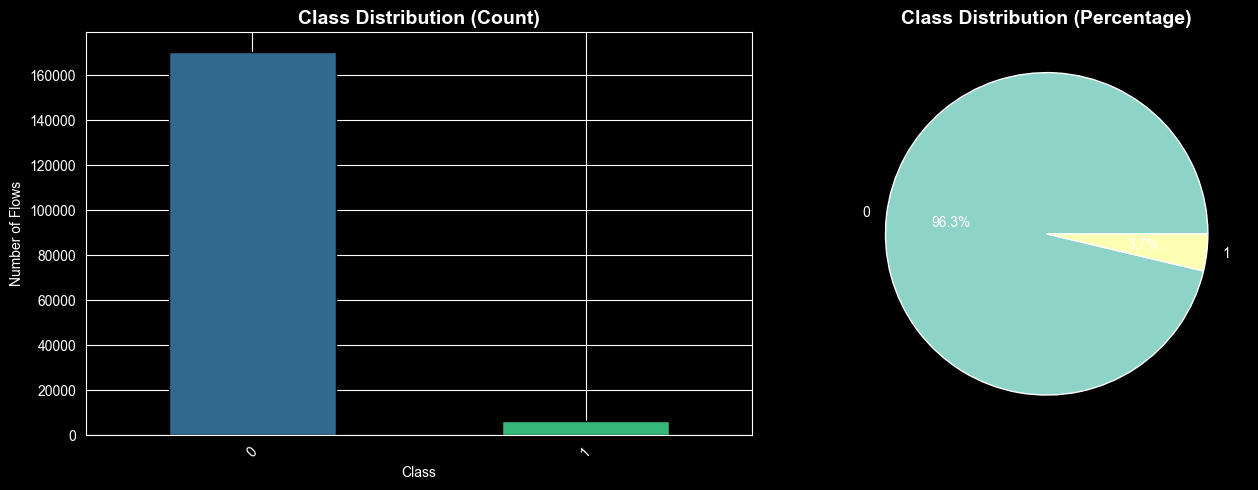


----------------------------------------
特征数据类型
----------------------------------------
int64      45
float64    25
Name: count, dtype: int64

[INFO] 非数值列: []
[INFO] 需要编码的类别特征: ['protocol']


In [19]:
# ============================================================================
# 1. 数据加载与探索性分析 (EDA)
# ============================================================================

print("\n" + "="*60)
print("1. 数据加载与探索")
print("="*60)

# 加载数据
df = pd.read_csv(CONFIG['data_path'])
df = df[(df['flow_id'] != 0) & (df['flow_start_timestamp_us'] != 0) &
                df['flow_id'].notna() & df['flow_start_timestamp_us'].notna()]
print(f"[INFO] 原始数据集形状: {df.shape}")
print(f"[INFO] 原始列数: {df.shape[1]}")
print(f"[INFO] 原始列名:\n{df.columns.tolist()}")

# ------------------------------------------------------------
# Step 1: 识别并确认标签列
# ------------------------------------------------------------
if CONFIG['label_col'] not in df.columns:
    print(f"\n[WARNING] 未找到指定标签列 '{CONFIG['label_col']}'")
    # 尝试常见标签列名
    possible_label_names = ['Label', 'label', 'class', 'Class', 'target', 'Target', 'category']
    found = False
    for name in possible_label_names:
        if name in df.columns:
            CONFIG['label_col'] = name
            found = True
            print(f"[INFO] 自动检测到标签列: '{name}'")
            break
    if not found:
        # 如果还是找不到，使用最后一列
        CONFIG['label_col'] = df.columns[-1]
        print(f"[INFO] 使用最后一列作为标签: '{CONFIG['label_col']}'")

print(f"\n[INFO] 最终标签列: '{CONFIG['label_col']}'")

# ------------------------------------------------------------
# Step 2: 排除不需要的列
# ------------------------------------------------------------
# 只排除实际存在于 DataFrame 中的列
excluded_found = [col for col in EXCLUDED_COLS if col in df.columns]
excluded_not_found = [col for col in EXCLUDED_COLS if col not in df.columns]

if excluded_not_found:
    print(f"\n[INFO] 以下排除列不在数据中（已忽略）: {excluded_not_found}")

if excluded_found:
    print(f"[INFO] 排除以下列: {excluded_found}")
    df = df.drop(columns=excluded_found)

print(f"[INFO] 排除后数据集形状: {df.shape}")

# ------------------------------------------------------------
# Step 3: 分离特征和标签
# ------------------------------------------------------------
# 从特征列中移除标签列
feature_cols = [col for col in df.columns if col != CONFIG['label_col']]
X = df[feature_cols].copy()
y = df[CONFIG['label_col']].copy()

print(f"\n[INFO] 特征维度: {X.shape[1]}")
print(f"[INFO] 标签列: '{CONFIG['label_col']}'")

# ------------------------------------------------------------
# Step 4: 标签分布分析
# ------------------------------------------------------------
print("\n" + "-"*40)
print("标签分布")
print("-"*40)
label_dist = y.value_counts()
print(label_dist)

# 可视化标签分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 条形图
colors = sns.color_palette('viridis', len(label_dist))
label_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=45)

# 饼图（小类合并为Other）
threshold_pct = 0.02
label_pct = label_dist / label_dist.sum()
major_labels = label_pct[label_pct >= threshold_pct].index
minor_sum = label_pct[label_pct < threshold_pct].sum()

pie_data = label_dist[major_labels].copy()
if minor_sum > 0:
    pie_data['Other'] = int(minor_sum * label_dist.sum())

pie_data.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
              colors=sns.color_palette('Set3', len(pie_data)),
              textprops={'fontsize': 10})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('mlp_baseline_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Step 5: 检查数据类型
# ------------------------------------------------------------
print("\n" + "-"*40)
print("特征数据类型")
print("-"*40)
dtype_counts = X.dtypes.value_counts()
print(dtype_counts)

# 找出所有非数值列
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\n[INFO] 非数值列: {non_numeric_cols}")

# 确认 CATEGORICAL_COLS 是否在数据中
categorical_found = [col for col in CATEGORICAL_COLS if col in X.columns]
categorical_not_found = [col for col in CATEGORICAL_COLS if col not in X.columns]
if categorical_not_found:
    print(f"[WARNING] 以下类别特征不在数据中: {categorical_not_found}")
if categorical_found:
    print(f"[INFO] 需要编码的类别特征: {categorical_found}")

In [20]:
# ============================================================================
# 2. 特征工程：处理类别特征与数值特征
# ============================================================================

print("\n" + "="*60)
print("2. 特征工程")
print("="*60)

# ------------------------------------------------------------
# Step 1: 处理无穷值和缺失值
# ------------------------------------------------------------
X = X.replace([np.inf, -np.inf], np.nan)
null_count = X.isnull().sum().sum()
if null_count > 0:
    print(f"[WARNING] 存在 {null_count} 个缺失值，使用中位数填充")
    X = X.fillna(X.median())

# ------------------------------------------------------------
# Step 2: 分离数值特征和类别特征
# ------------------------------------------------------------
# 数值特征：所有数值型的列，但要排除掉 CATEGORICAL_COLS 中明确指定的
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# 确保 CATEGORICAL_COLS 中的列（即使它是数值）被当作类别处理
numerical_cols = [col for col in numerical_cols if col not in categorical_found]

print(f"[INFO] 数值特征数量: {len(numerical_cols)}")
print(f"[INFO] 类别特征数量: {len(categorical_found)}")
if categorical_found:
    for col in categorical_found:
        unique_vals = X[col].nunique()
        print(f"  - {col}: {unique_vals} 个唯一值 (dtype: {X[col].dtype})")

# ------------------------------------------------------------
# Step 3: One-Hot 编码类别特征（替换原来的 Label Encoding）
# ------------------------------------------------------------
if categorical_found:
    # 使用 pd.get_dummies 进行 One-Hot 编码
    # drop_first=False: 保留所有类别列（不丢掉参考类别）
    # 这样每个类别都有独立的列，模型更容易学习
    X_categorical_onehot = pd.get_dummies(
        X[categorical_found],
        columns=categorical_found,
        drop_first=False,      # 保留所有类别
        prefix_sep='_',        # 前缀分隔符
        dtype=int               # 使用 int 而非 bool
    )

    print(f"[INFO] One-Hot 编码完成")
    print(f"[INFO] 原始类别特征: {len(categorical_found)} 列")
    print(f"[INFO] One-Hot 后新增: {X_categorical_onehot.shape[1]} 列")

    # 打印编码详情
    for col in categorical_found:
        onehot_cols = [c for c in X_categorical_onehot.columns if c.startswith(f'{col}_')]
        print(f"  {col}: {len(onehot_cols)} 个 One-Hot 列")
        if len(onehot_cols) <= 10:  # 如果类别不太多，打印映射关系
            for ocol in onehot_cols:
                print(f"    -> {ocol}")

    # 将 One-Hot 编码与数值特征合并
    X_numerical = X[numerical_cols].copy()
    X_processed = pd.concat([X_numerical, X_categorical_onehot], axis=1)
else:
    X_processed = X[numerical_cols].copy()

print(f"\n[INFO] 处理后特征维度: {X_processed.shape[1]}")
print(f"[INFO] 处理后列名:\n{X_processed.columns.tolist()}")

# ------------------------------------------------------------
# Step 4: 编码标签
# ------------------------------------------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
# class_names = label_encoder.classes_
class_names = [str(name) for name in label_encoder.classes_]

print(f"\n[INFO] 标签编码完成")
print(f"[INFO] 类别数量: {num_classes}")
print(f"[INFO] 类别名称与编码映射:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} -> '{name}': {count:,} 样本")


2. 特征工程
[INFO] 数值特征数量: 69
[INFO] 类别特征数量: 1
  - protocol: 6 个唯一值 (dtype: int64)
[INFO] One-Hot 编码完成
[INFO] 原始类别特征: 1 列
[INFO] One-Hot 后新增: 6 列
  protocol: 6 个 One-Hot 列
    -> protocol_1
    -> protocol_4
    -> protocol_6
    -> protocol_17
    -> protocol_50
    -> protocol_58

[INFO] 处理后特征维度: 75
[INFO] 处理后列名:
['flow_id', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes_per_s', 'flow_packets_per_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_len

In [21]:
# ============================================================================
# 3. 数据划分与标准化
# ============================================================================

print("\n" + "="*60)
print("3. 数据划分与标准化")
print("="*60)

# ------------------------------------------------------------
# Step 1: 分层划分
# ------------------------------------------------------------
# 先分出测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded,
    test_size=CONFIG['test_size'],
    stratify=y_encoded,
    random_state=42
)

# 从训练集中分出验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
    stratify=y_train,
    random_state=42
)

print(f"[INFO] 数据划分结果:")
print(f"  训练集: {len(X_train):,} 样本")
print(f"  验证集: {len(X_val):,} 样本")
print(f"  测试集: {len(X_test):,} 样本")

# 检查划分后的类别分布
print(f"\n[INFO] 训练集类别分布:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for i, count in train_dist.items():
    pct = count / len(y_train) * 100
    print(f"  {class_names[i]}: {count:,} ({pct:.2f}%)")

# ------------------------------------------------------------
# Step 2: 标准化（仅在训练集上拟合）
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n[INFO] 标准化完成")
print(f"  训练集均值: {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"  训练集标准差: {X_train_scaled.std(axis=0).mean():.6f}")

# 将 numpy array 转回 DataFrame 用于后续（可选）
feature_names = X_processed.columns.tolist()


3. 数据划分与标准化
[INFO] 数据划分结果:
  训练集: 123,935 样本
  验证集: 17,705 样本
  测试集: 35,410 样本

[INFO] 训练集类别分布:
  0: 119,346 (96.30%)
  1: 4,589 (3.70%)

[INFO] 标准化完成
  训练集均值: -0.000000
  训练集标准差: 0.946667


In [22]:
# ============================================================================
# 4. PyTorch 数据集与数据加载器
# ============================================================================

class FlowDataset(Dataset):
    """流级别数据集

    输入: 流统计特征 s_i (shape: [num_features])
    输出: 类别标签

    这对应提案中的 Section 5.3.1 MLP Baseline:
    仅使用 s_i（流级别聚合统计特征），不涉及任何数据包序列
    """
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# 创建数据集
train_dataset = FlowDataset(X_train_scaled, y_train)
val_dataset = FlowDataset(X_val_scaled, y_val)
test_dataset = FlowDataset(X_test_scaled, y_test)

# 创建数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"\n[INFO] 数据加载器创建完成")
print(f"  训练批次数: {len(train_loader)} (batch_size={CONFIG['batch_size']})")
print(f"  验证批次数: {len(val_loader)}")
print(f"  测试批次数: {len(test_loader)}")

# ------------------------------------------------------------
# 计算类别权重（处理不平衡数据）
# ------------------------------------------------------------
if CONFIG['use_class_weights']:
    class_counts = np.bincount(y_train)
    total = len(y_train)
    # class_weight = n_samples / (n_classes * n_samples_per_class)
    class_weights = total / (num_classes * class_counts)
    # 对样本数极少的类，限制权重上限避免训练不稳定
    class_weights = np.clip(class_weights, 0.1, 10.0)
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"\n[INFO] 类别权重 (已裁剪到 [0.1, 10.0]):")
    for i, w in enumerate(class_weights.cpu().numpy()):
        print(f"  {class_names[i]}: {w:.4f} (样本数: {class_counts[i]})")
else:
    class_weights = None


[INFO] 数据加载器创建完成
  训练批次数: 485 (batch_size=256)
  验证批次数: 70
  测试批次数: 139

[INFO] 类别权重 (已裁剪到 [0.1, 10.0]):
  0: 0.5192 (样本数: 119346)
  1: 10.0000 (样本数: 4589)


In [23]:
# ============================================================================
# 5. MLP 模型定义
# ============================================================================

class MLPClassifier(nn.Module):
    """
    多层感知机分类器 - MLP Baseline

    对应提案 Section 5.3.1:
    输入仅为流级别统计特征 s_i，不使用任何数据包序列信息。

    架构设计:
    - 输入层: [batch, input_dim]
    - 隐藏层: 多个全连接层 + BatchNorm + GELU + Dropout
    - 输出层: [batch, num_classes]

    设计理由:
    - BatchNorm1d: 稳定训练，加速收敛
    - GELU: 现代激活函数，在负值区域更平滑的梯度
    - Dropout: 防止过拟合，特别是在小类上
    """
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3):
        super(MLPClassifier, self).__init__()

        # 构建隐藏层
        layers = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)

        # 分类头
        self.classifier = nn.Linear(prev_dim, num_classes)

        # 初始化
        self._init_weights()

    def _init_weights(self):
        """Xavier/Glorot 初始化，适合 GELU 激活"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        """提取中间特征（用于可视化或迁移学习）"""
        return self.feature_extractor(x)

# 实例化模型
input_dim = X_train_scaled.shape[1]
model = MLPClassifier(
    input_dim=input_dim,
    hidden_dims=CONFIG['hidden_dims'],
    num_classes=num_classes,
    dropout=CONFIG['dropout']
).to(device)

# 打印模型摘要
print("\n" + "="*60)
print("5. 模型架构")
print("="*60)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[INFO] 输入维度: {input_dim}")
print(f"[INFO] 隐藏层维度: {CONFIG['hidden_dims']}")
print(f"[INFO] 输出类别数: {num_classes}")
print(f"[INFO] 总参数量: {total_params:,}")
print(f"[INFO] 可训练参数量: {trainable_params:,}")

# 计算模型大小
model_size_mb = total_params * 4 / (1024 * 1024)  # 假设 float32
print(f"[INFO] 模型大小: {model_size_mb:.2f} MB")


5. 模型架构
MLPClassifier(
  (feature_extractor): Sequential(
    (0): Linear(in_features=75, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): GELU(approximate='none')
    (15): Dropout(p=0.25, inplace=False)
  )
  (classifier): Linear(in_feat

In [24]:
# ============================================================================
# 6. 损失函数、训练函数与完整评估函数
# ============================================================================

class ClassBalancedFocalLoss(nn.Module):
    """自包含的 Class-Balanced Focal Loss，避免依赖项目外部模块。"""
    def __init__(self, labels, num_classes, beta=0.999, gamma=1.5,
                 label_smoothing=0.0, device=None):
        super().__init__()
        counts = np.bincount(np.asarray(labels, dtype=np.int64), minlength=num_classes)
        effective_num = 1.0 - np.power(beta, counts)
        weights = (1.0 - beta) / np.maximum(effective_num, 1e-12)
        weights = weights / weights.sum() * num_classes
        self.register_buffer('weights', torch.tensor(weights, dtype=torch.float32))
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets,
            weight=self.weights,
            reduction='none',
            label_smoothing=self.label_smoothing
        )
        pt = torch.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_factor = (1.0 - pt).pow(self.gamma)
        return (focal_factor * ce).mean()


def train_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch。"""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for features, labels in loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * features.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    return (
        avg_loss,
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    )


def predict_loader(model, loader, criterion, device):
    """一次前向推理，返回 loss、真实标签和每类概率。"""
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(features)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item() * features.size(0)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    return (
        total_loss / len(loader.dataset),
        np.concatenate(all_labels),
        np.concatenate(all_probs)
    )


def predictions_from_probs(probs, threshold=0.5):
    """二分类使用可调阈值；多分类使用 argmax。"""
    if probs.shape[1] == 2:
        return (probs[:, 1] >= threshold).astype(np.int64)
    return probs.argmax(axis=1).astype(np.int64)


def find_best_binary_threshold(y_true, positive_probs, metric='macro_f1',
                               threshold_min=0.05, threshold_max=0.95,
                               threshold_step=0.005):
    """只在验证集搜索阈值，避免利用测试集调参。"""
    thresholds = np.arange(
        threshold_min,
        threshold_max + threshold_step / 2,
        threshold_step
    )
    best_threshold, best_score = 0.5, -np.inf

    for threshold in thresholds:
        pred = (positive_probs >= threshold).astype(np.int64)
        if metric == 'f1_label1':
            score = f1_score(y_true, pred, pos_label=1, average='binary', zero_division=0)
        else:
            score = f1_score(y_true, pred, average='macro', zero_division=0)

        # 分数相同时优先选择更接近 0.5 的阈值，保证结果稳定
        if score > best_score + 1e-12 or (
            abs(score - best_score) <= 1e-12 and
            abs(threshold - 0.5) < abs(best_threshold - 0.5)
        ):
            best_threshold, best_score = float(threshold), float(score)

    return best_threshold, best_score


def calculate_full_metrics(y_true, probs, loss, threshold=0.5, class_names=None):
    """生成用户要求的完整指标字典。"""
    y_true = np.asarray(y_true, dtype=np.int64)
    probs = np.asarray(probs, dtype=np.float64)
    preds = predictions_from_probs(probs, threshold)
    n_classes = probs.shape[1]

    per_f1 = f1_score(
        y_true, preds,
        labels=np.arange(n_classes),
        average=None,
        zero_division=0
    )
    names = class_names if class_names is not None else [str(i) for i in range(n_classes)]

    metrics = {
        'accuracy': float(accuracy_score(y_true, preds)),
        'macro_precision': float(precision_score(y_true, preds, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, preds, average='macro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, preds, average='macro', zero_division=0)),
        'weighted_precision': float(precision_score(y_true, preds, average='weighted', zero_division=0)),
        'weighted_recall': float(recall_score(y_true, preds, average='weighted', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, preds, average='weighted', zero_division=0)),
        'per_class_f1': {str(names[i]): float(per_f1[i]) for i in range(n_classes)},
        'confusion_matrix': confusion_matrix(
            y_true, preds, labels=np.arange(n_classes)
        ).astype(int).tolist(),
        'num_classes': int(n_classes),
        'num_samples': int(len(y_true)),
        'loss': float(loss),
        'threshold': float(threshold) if n_classes == 2 else None,
    }

    if n_classes == 2:
        positive_probs = probs[:, 1]
        metrics.update({
            'precision_label1': float(precision_score(y_true, preds, pos_label=1, average='binary', zero_division=0)),
            'recall_label1': float(recall_score(y_true, preds, pos_label=1, average='binary', zero_division=0)),
            'f1_label1': float(f1_score(y_true, preds, pos_label=1, average='binary', zero_division=0)),
            'auc': float(roc_auc_score(y_true, positive_probs)),
            'pr_auc': float(average_precision_score(y_true, positive_probs)),
        })
    else:
        y_onehot = np.eye(n_classes, dtype=np.int64)[y_true]
        metrics.update({
            'auc': float(roc_auc_score(y_onehot, probs, multi_class='ovr', average='macro')),
            'pr_auc': float(average_precision_score(y_onehot, probs, average='macro')),
        })

    # 调整键顺序，使输出与目标 Full metrics 格式一致
    ordered_keys = [
        'accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
        'weighted_precision', 'weighted_recall', 'weighted_f1'
    ]
    if n_classes == 2:
        ordered_keys += ['precision_label1', 'recall_label1', 'f1_label1']
    ordered_keys += [
        'auc', 'pr_auc', 'per_class_f1', 'confusion_matrix',
        'num_classes', 'num_samples', 'loss', 'threshold'
    ]
    return {key: metrics[key] for key in ordered_keys}


def evaluate(model, loader, criterion, device, threshold=0.5, class_names=None):
    """兼容训练循环的评估接口，同时返回完整指标、预测和概率。"""
    loss, labels, probs = predict_loader(model, loader, criterion, device)
    full_metrics = calculate_full_metrics(
        labels, probs, loss=loss,
        threshold=threshold,
        class_names=class_names
    )
    preds = predictions_from_probs(probs, threshold)
    return full_metrics, preds, labels, probs


In [25]:
# ============================================================================
# 7. 训练循环
# ============================================================================

print("\n" + "="*60)
print("7. 开始训练")
print("="*60)

# 损失函数：自包含实现，不再依赖 from s1.stage1.losses import ...
if CONFIG['use_class_weights']:
    criterion = ClassBalancedFocalLoss(
        labels=y_train,
        num_classes=num_classes,
        beta=0.999,
        gamma=1.5,
        label_smoothing=0.0
    ).to(device)
    print("[INFO] 使用 Class-Balanced Focal Loss")
else:
    criterion = nn.CrossEntropyLoss()
    print("[INFO] 使用标准 CrossEntropyLoss")

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = {
    'train_loss': [], 'train_f1_macro': [], 'train_f1_weighted': [],
    'val_loss': [], 'val_f1_macro': [], 'val_f1_weighted': [], 'val_auc': []
}

best_val_f1 = -np.inf
best_epoch = 0
patience_counter = 0
best_model_state = None

print("\n" + "-"*96)
print(f"{'Epoch':<7}{'Train Loss':<13}{'Train Macro-F1':<17}{'Val Loss':<13}"
      f"{'Val Macro-F1':<16}{'Val AUC':<12}{'LR':<10}")
print("-"*96)

for epoch in range(CONFIG['num_epochs']):
    train_loss, train_f1_macro, train_f1_weighted = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # 训练阶段统一用 0.5 阈值评估；最佳阈值将在最佳模型加载后单独搜索
    val_metrics, _, _, _ = evaluate(
        model, val_loader, criterion, device,
        threshold=0.5, class_names=class_names
    )
    val_loss = val_metrics['loss']
    val_f1_macro = val_metrics['macro_f1']
    val_f1_weighted = val_metrics['weighted_f1']
    val_auc = val_metrics['auc']

    history['train_loss'].append(train_loss)
    history['train_f1_macro'].append(train_f1_macro)
    history['train_f1_weighted'].append(train_f1_weighted)
    history['val_loss'].append(val_loss)
    history['val_f1_macro'].append(val_f1_macro)
    history['val_f1_weighted'].append(val_f1_weighted)
    history['val_auc'].append(val_auc)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<7}{train_loss:<13.5f}{train_f1_macro:<17.5f}"
              f"{val_loss:<13.5f}{val_f1_macro:<16.5f}{val_auc:<12.6f}{current_lr:<10.6f}")

    if val_f1_macro > best_val_f1 + 1e-12:
        best_val_f1 = val_f1_macro
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        patience_counter += 1

    if patience_counter >= CONFIG['early_stop_patience']:
        print(f"\n[INFO] 早停触发：Epoch {epoch + 1}")
        break

if best_model_state is None:
    raise RuntimeError("训练未产生可用的最佳模型参数。")

model.load_state_dict(best_model_state)
model.to(device)
print(f"[INFO] 已加载最佳模型：Epoch {best_epoch}, Val Macro-F1={best_val_f1:.6f}")

# 只用验证集确定二分类阈值
if num_classes == 2:
    val_loss, val_labels, val_probs = predict_loader(
        model, val_loader, criterion, device
    )
    best_threshold, best_threshold_score = find_best_binary_threshold(
        val_labels,
        val_probs[:, 1],
        metric=CONFIG['threshold_metric'],
        threshold_min=CONFIG['threshold_min'],
        threshold_max=CONFIG['threshold_max'],
        threshold_step=CONFIG['threshold_step']
    )
    print(
        f"[INFO] 验证集最佳阈值: {best_threshold:.3f} | "
        f"{CONFIG['threshold_metric']}={best_threshold_score:.6f}"
    )
else:
    best_threshold = 0.5



7. 开始训练
[INFO] 使用 Class-Balanced Focal Loss

------------------------------------------------------------------------------------------------
Epoch  Train Loss   Train Macro-F1   Val Loss     Val Macro-F1    Val AUC     LR        
------------------------------------------------------------------------------------------------
1      0.05504      0.60264          0.03270      0.71401         0.946311    0.001000  
5      0.03046      0.71593          0.02836      0.70842         0.963242    0.001000  
10     0.02881      0.73365          0.02802      0.69369         0.965780    0.001000  
15     0.02786      0.74535          0.03033      0.76193         0.959179    0.001000  
20     0.02749      0.74793          0.02690      0.74708         0.967136    0.001000  
25     0.02698      0.75614          0.02721      0.70326         0.966993    0.001000  
30     0.02639      0.76230          0.02723      0.73476         0.966066    0.001000  

[INFO] 早停触发：Epoch 30
[INFO] 已加载最佳模型：Epoch 15, V

In [26]:
# ============================================================================
# 8. 测试集最终评估：输出全部 Full metrics
# ============================================================================

import json

print("\n" + "="*60)
print("8. 测试集最终评估")
print("="*60)

full_metrics, test_preds, test_labels, test_probs = evaluate(
    model,
    test_loader,
    criterion,
    device,
    threshold=best_threshold,
    class_names=class_names
)

print("\nFull metrics:")
print(full_metrics)

print("\n[RESULT] 各类别详细指标:")
print(classification_report(
    test_labels,
    test_preds,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=6,
    zero_division=0
))

# 后续可视化单元继续使用这些变量
per_class_f1 = np.array([
    full_metrics['per_class_f1'][str(name)] for name in class_names
])
test_loss = full_metrics['loss']
test_f1_macro = full_metrics['macro_f1']
test_f1_weighted = full_metrics['weighted_f1']
test_auc = full_metrics['auc']

results = {
    'model_name': 'MLP Baseline',
    'input_dim': int(input_dim),
    'hidden_dims': CONFIG['hidden_dims'],
    'num_params': int(total_params),
    'best_epoch': int(best_epoch),
    'best_val_f1': float(best_val_f1),
    'full_metrics': full_metrics
}

with open('mlp_full_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(full_metrics, file, ensure_ascii=False, indent=2)

with open('mlp_results.json', 'w', encoding='utf-8') as file:
    json.dump(results, file, ensure_ascii=False, indent=2)

# 保存推理所需对象
checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'hidden_dims': CONFIG['hidden_dims'],
    'num_classes': num_classes,
    'class_names': class_names,
    'feature_names': feature_names,
    'threshold': best_threshold,
    'config': CONFIG
}
torch.save(checkpoint, 'mlp_best_model.pt')

import joblib
joblib.dump(scaler, 'mlp_scaler.joblib')
joblib.dump(label_encoder, 'mlp_label_encoder.joblib')

print("\n[INFO] 已保存:")
print("  - mlp_full_metrics.json")
print("  - mlp_results.json")
print("  - mlp_best_model.pt")
print("  - mlp_scaler.joblib")
print("  - mlp_label_encoder.joblib")



8. 测试集最终评估

Full metrics:
{'accuracy': 0.9626659135837334, 'macro_precision': 0.74145487832394, 'macro_recall': 0.809354661189905, 'macro_f1': 0.7706508462917445, 'weighted_precision': 0.9680282703050128, 'weighted_recall': 0.9626659135837334, 'weighted_f1': 0.9649653532784647, 'precision_label1': 0.4967628016480283, 'recall_label1': 0.6437833714721587, 'f1_label1': 0.5607973421926911, 'auc': 0.9552327656163553, 'pr_auc': 0.5604476128764463, 'per_class_f1': {'0': 0.9805043503907979, '1': 0.5607973421926911}, 'confusion_matrix': [[33244, 855], [467, 844]], 'num_classes': 2, 'num_samples': 35410, 'loss': 0.031577753180528016, 'threshold': 0.42999999999999977}

[RESULT] 各类别详细指标:
              precision    recall  f1-score   support

           0   0.986147  0.974926  0.980504     34099
           1   0.496763  0.643783  0.560797      1311

    accuracy                       0.962666     35410
   macro avg   0.741455  0.809355  0.770651     35410
weighted avg   0.968028  0.962666  0.96496


9. 结果可视化


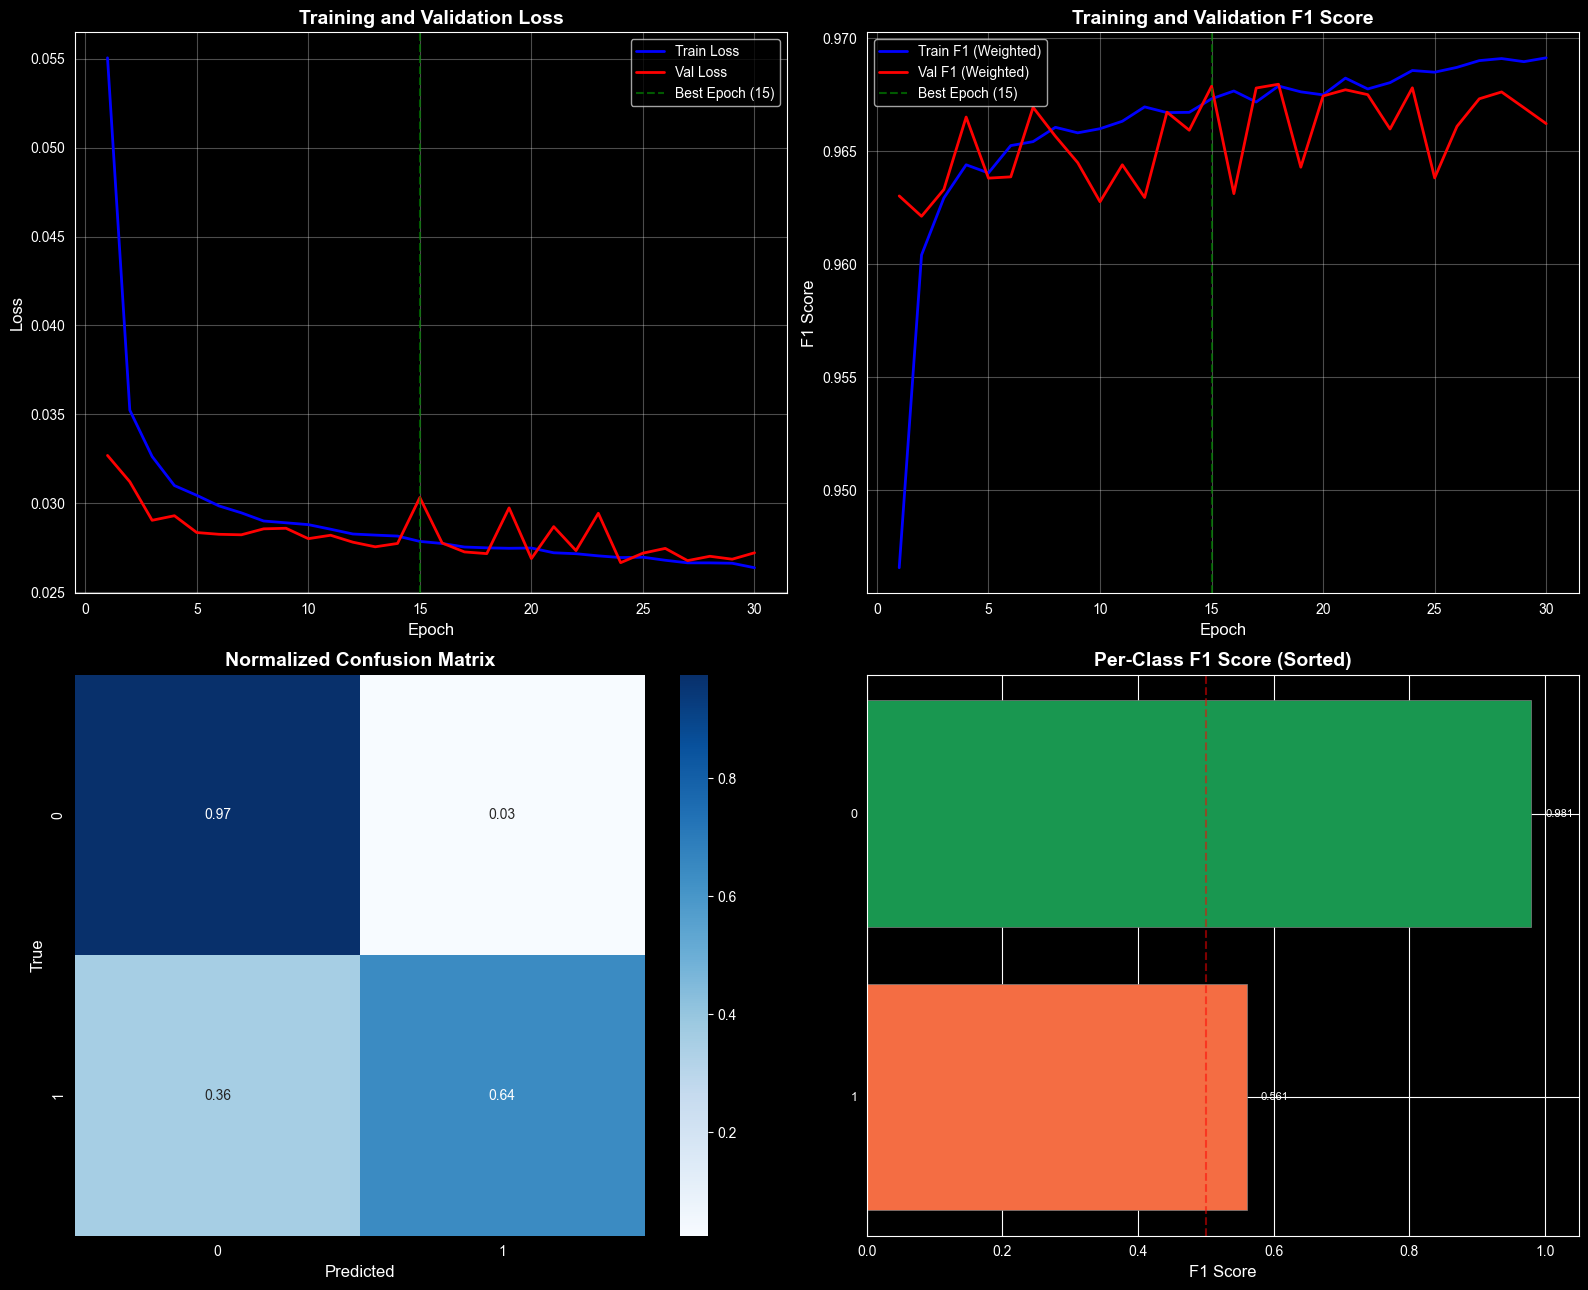

In [27]:
# ============================================================================
# 9. 结果可视化
# ============================================================================

print("\n" + "="*60)
print("9. 结果可视化")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# ------------------------------------------------------------
# 子图1: 训练损失曲线
# ------------------------------------------------------------
ax1 = axes[0, 0]
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 子图2: F1 分数曲线
# ------------------------------------------------------------
ax2 = axes[0, 1]
ax2.plot(epochs_range, history['train_f1_weighted'], 'b-',
         label='Train F1 (Weighted)', linewidth=2)
ax2.plot(epochs_range, history['val_f1_weighted'], 'r-',
         label='Val F1 (Weighted)', linewidth=2)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best Epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 子图3: 归一化混淆矩阵
# ------------------------------------------------------------
ax3 = axes[1, 0]
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 如果类别太多，只显示混淆明显的部分
if num_classes > 20:
    # 只显示 F1 较低的类（容易混淆的）
    confusable_classes = np.argsort(per_class_f1)[:15]
    cm_subset = cm_normalized[confusable_classes][:, confusable_classes]
    class_subset = class_names[confusable_classes]
    sns.heatmap(cm_subset, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_subset, yticklabels=class_subset, ax=ax3)
    ax3.set_title('Normalized Confusion Matrix (Top Confusable Classes)',
                  fontsize=14, fontweight='bold')
else:
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax3)
    ax3.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('True', fontsize=12)

# ------------------------------------------------------------
# 子图4: 各类别 F1 分数条形图
# ------------------------------------------------------------
ax4 = axes[1, 1]
# 按 F1 排序
sorted_indices = np.argsort(per_class_f1)
sorted_f1 = per_class_f1[sorted_indices]
# sorted_names = class_names[sorted_indices]
# 修复：将 class_names 转为 numpy array，或使用列表推导式
sorted_names = np.array(class_names)[sorted_indices]  # 方案1
# 或者：sorted_names = [class_names[i] for i in sorted_indices]  # 方案2

# 颜色映射：F1 越高越绿，越低越红
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_f1)))

bars = ax4.barh(range(len(sorted_f1)), sorted_f1, color=colors, edgecolor='gray', linewidth=0.5)
ax4.set_yticks(range(len(sorted_f1)))
ax4.set_yticklabels(sorted_names, fontsize=9)
ax4.set_xlabel('F1 Score', fontsize=12)
ax4.set_title('Per-Class F1 Score (Sorted)', fontsize=14, fontweight='bold')
ax4.set_xlim(0, 1.05)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='F1=0.5')

# 标注数值
for bar, val in zip(bars, sorted_f1):
    ax4.text(min(val + 0.02, 1.02), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('mlp_baseline_results.png', dpi=200, bbox_inches='tight')
plt.show()
